# Week 9 Capstone: recovered rounds and Expected Improvement

Week 9 contains two complete missing rounds (Weeks 3 and 4). This notebook validates and appends them, increasing verified evidence from 199 to 215 observations, while leaving incomplete/conflicting Weeks 5 and 7 pending. It then performs reproducible 80% local / 20% global Expected Improvement optimisation.

## Errors found and corrected

1. `/content/week_8_data.zip`, text files, Google Drive, and all `/content` paths are unavailable.
2. Regex-flattening text then slicing by dimension repeats the exact mechanism that previously shifted values between functions. Function-grouped arrays are used directly.
3. The 'integrity fixer' silently trims inputs or outputs to the shorter length, permanently discarding evidence and potentially hiding misalignment. Mismatches now raise errors.
4. `week9_path` is used before it is defined in the original cell order.
5. `display()` is assumed without importing it, making execution environment-dependent.
6. Weeks 3 and 4 are recoverable, but later output arrays 6–8 lack matching input arrays and cannot be appended.
7. `inputs_5/outputs_5` conflicts with the explicit Week 7 record for F3, F7, and F8, so the higher-confidence grouped Week 7 values are retained and the conflict documented.
8. Candidate duplicate removal used slow Python sets before six-decimal proposal rounding and did not guarantee the selected rounded point was new.
9. Global random seeding and eight separate BO execution cells made results stateful.
10. The oversized Matern + RBF + RationalQuadratic kernel is weakly identifiable for these small datasets and expensive to optimise. A fitted Matern composite is used consistently.
11. Raw cross-function plots mix incompatible scales. Within-function percentiles, uncertainty, EI, and exploration distance are compared instead.
12. Drive CSV writes and summaries claiming absent data was confirmed were removed.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}
ROUNDS_Q={
1:[[.375440,.950714],[.536429,.835362],[.614168,.334143],[.872626,.321598]],
2:[[.375440,.950714],[.978752,.932731],[.000006,.334143],[.197553,.808683]],
3:[[.444444,.666666,.333333],[.657452,.998464,.817253],[.670026,.057881,.658241],[.650132,.218327,.110542]],
4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202],[.394519,.361122,.256803,.461856],[.715715,.504442,.275065,.552962]],
5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260],[.255842,.841692,.888985,.860266],[0.,0.,0.,0.]],
6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321],[.495070,.097152,.672921,.000007,.351268],[.973181,.022807,.714484,.145453,.974790]],
7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324],[.143585,.302559,.571101,.194533,.395561,.815792],[.045103,.016167,.773003,.156031,.147073,.616114]],
8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846],[.088894,.525132,.030986,.992538,.870819,.217060,.011239,.447691],[.356502,.157574,.172997,.610561,.106477,.260297,.411421,.904740]]}
ROUNDS_Y={1:[-1.560646704467778e-117,1.674933466363685e-36,-1.0755942664604116e-32,-2.4666412561217706e-107],2:[-.03182956281754251,.022666631114895516,.04868370128566149,.038774938576018964],3:[-.04090761844901528,-.08987474979637637,-.18323876643005035,-.08251349582236739],4:[-8.727516493155957,-31.73535839431216,-1.9810750402526334,-9.312811809021998],5:[1088.8535114737463,1035.6341457754475,1035.6647479285914,163.1225],6:[-1.1520351120911565,-.8782405650300305,-1.339542402620705,-2.4375082517089726],7:[1.0510148516295004,.308765180253091,2.149905456773691,1.2087334449610816],8:[9.8157087929671,9.9399041910574,8.9636037557014,9.2540644925525]}
W6Q={1:[.897714,.081699],2:[.555332,.360931],3:[.522231,.090709,.451742],4:[.713766,.198601,.014095,.068347],5:[.754614,.504566,.432986,.307039],6:[.824244,.022732,.960907,.041715,.897560],7:[.052337,.910075,.727790,.075231,.386516,.492629],8:[.110992,.462977,.255313,.963757,.895383,.716713,.030436,.083412]}
W6Y={1:7.651210225556565e-239,2:.22078072799826579,3:-.05739710166867316,4:-17.92630659900679,5:.9401160531598542,6:-2.5293691850310744,7:.19078262729854223,8:9.1386093133071}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_09').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}), got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: input/output mismatch.')
    if X.dtype==object or y.dtype==object or not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: invalid numeric data.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: input outside [0,1].')
def load_verified(fn):
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; X=np.asarray(np.load(folder/'initial_inputs.npy',allow_pickle=False),float); y=np.asarray(np.load(folder/'initial_outputs.npy',allow_pickle=False),float).reshape(-1); validate(fn,X,y)
    for round_number,(q,v) in enumerate(zip(ROUNDS_Q[fn],ROUNDS_Y[fn]),1):
        q=np.asarray(q,float)
        if q.shape!=(DIMS[fn],): raise ValueError(f'F{fn}, round {round_number}: wrong dimension.')
        X=np.vstack((X,q)); y=np.append(y,v)
    q6=np.asarray(W6Q[fn],float); X=np.vstack((X,q6)); y=np.append(y,W6Y[fn]); validate(fn,X,y); return X,y

## Function-by-function recovered-evidence review

The two newly recovered rounds are included before the independently recorded Week 6 return. Weeks 5 and 7 remain pending.

In [3]:
def summarize(fn):
    X,y=load_verified(fn); best=int(np.argmax(y)); recovered_start=len(y)-3; before=np.max(y[:recovered_start])
    return {'Function':f'F{fn}','Dimensions':DIMS[fn],'Verified observations':len(y),'Best before recovered Week 3/4':float(before),'Recovered Week 3 return':float(y[-3]),'Recovered Week 4 return':float(y[-2]),'Latest recoverable':float(y[-1]),'Verified best':float(y[best]),'Recovered-round improvement':float(np.max(y[:len(y)-1])-before),'Latest percentile':100*float(np.mean(y[:-1]<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Evidence gaps':'Weeks 5 and 7 pending'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Dimensions,Verified observations,Best before recovered Week 3/4,Recovered Week 3 return,Recovered Week 4 return,Latest recoverable,Verified best,Recovered-round improvement,Latest percentile,Best query,Best input,Evidence gaps
0,F1,2,15,7.710875e-16,-1.075594e-32,-2.466641e-107,7.651210e-239,7.710875e-16,0.000000,42.857143,3,"[0.7310236309563586, 0.7329998764152272]",Weeks 5 and 7 pending
1,F2,2,15,6.112052e-01,4.868370e-02,3.877494e-02,2.207807e-01,6.112052e-01,0.000000,64.285714,10,"[0.7026365569244406, 0.9265641975455574]",Weeks 5 and 7 pending
2,F3,3,20,-3.483531e-02,-1.832388e-01,-8.251350e-02,-5.739710e-02,-3.483531e-02,0.000000,68.421053,4,"[0.49258141463713434, 0.6115931882759961, 0.34...",Weeks 5 and 7 pending
3,F4,4,35,-4.025542e+00,-1.981075e+00,-9.312812e+00,-1.792631e+01,-1.981075e+00,2.044467,32.352941,33,"[0.394519, 0.361122, 0.256803, 0.461856]",Weeks 5 and 7 pending
4,F5,4,25,1.088860e+03,1.035665e+03,1.631225e+02,9.401161e-01,1.088860e+03,0.000000,4.166667,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",Weeks 5 and 7 pending
5,F6,5,25,-7.142649e-01,-1.339542e+00,-2.437508e+00,-2.529369e+00,-7.142649e-01,0.000000,4.166667,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",Weeks 5 and 7 pending
6,F7,6,35,1.364968e+00,2.149905e+00,1.208733e+00,1.907826e-01,2.149905e+00,0.784937,55.882353,33,"[0.143585, 0.302559, 0.571101, 0.194533, 0.395...",Weeks 5 and 7 pending
7,F8,8,45,9.939904e+00,8.963604e+00,9.254064e+00,9.138609e+00,9.939904e+00,0.000000,84.090909,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...",Weeks 5 and 7 pending


In [4]:
for r in performance.to_dict('records'):
    status='IMPROVED' if r['Recovered-round improvement']>0 else 'NO RECOVERED IMPROVEMENT'
    print(f"{r['Function']} — {status}")
    print(f"  observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  recovered Week 3={r['Recovered Week 3 return']:.12g}, Week 4={r['Recovered Week 4 return']:.12g}")
    print(f"  latest={r['Latest recoverable']:.12g}, verified best={r['Verified best']:.12g}")
    print(f"  gaps: {r['Evidence gaps']}")

F1 — NO RECOVERED IMPROVEMENT
  observations=15, dimensions=2
  recovered Week 3=-1.07559426646e-32, Week 4=-2.46664125612e-107
  latest=7.65121022556e-239, verified best=7.7108751145e-16
  gaps: Weeks 5 and 7 pending
F2 — NO RECOVERED IMPROVEMENT
  observations=15, dimensions=2
  recovered Week 3=0.0486837012857, Week 4=0.038774938576
  latest=0.220780727998, verified best=0.611205215761
  gaps: Weeks 5 and 7 pending
F3 — NO RECOVERED IMPROVEMENT
  observations=20, dimensions=3
  recovered Week 3=-0.18323876643, Week 4=-0.0825134958224
  latest=-0.0573971016687, verified best=-0.0348353133501
  gaps: Weeks 5 and 7 pending
F4 — IMPROVED
  observations=35, dimensions=4
  recovered Week 3=-1.98107504025, Week 4=-9.31281180902
  latest=-17.926306599, verified best=-1.98107504025
  gaps: Weeks 5 and 7 pending
F5 — NO RECOVERED IMPROVEMENT
  observations=25, dimensions=4
  recovered Week 3=1035.66474793, Week 4=163.1225
  latest=0.94011605316, verified best=1088.8596182
  gaps: Weeks 5 and 

## Week 9 Expected Improvement proposals

Each function evaluates 800 local candidates around its top five observations and 200 global candidates. Selection uses maximisation EI with ξ=0.01.

In [5]:
def ei(mean,std,best,xi=.01):
    safe=np.maximum(std,1e-12); delta=mean-best-xi; z=delta/safe; values=delta*norm.cdf(z)+safe*norm.pdf(z); values[std<=1e-12]=0; return values
def propose(fn,X,y,rng):
    d=X.shape[1]; top=X[np.argsort(y)[-5:]]; bases=top[rng.integers(0,len(top),800)]; local=np.clip(bases+rng.normal(0,.05,(800,d)),0,1); points=np.vstack((local,rng.uniform(0,1,(200,d))))
    kernel=ConstantKernel(1.,(1e-3,1e3))*Matern(np.ones(d),(1e-2,1e2),nu=2.5)+WhiteKernel(1e-5,(1e-10,1e1)); gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    mean,std=gp.predict(points,return_std=True); values=ei(mean,std,np.max(y))
    for idx in np.argsort(values)[::-1]:
        q=np.round(points[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)):
            return {'query':q,'kernel':str(gp.kernel_),'mean':float(mean[idx]),'std':float(std[idx]),'ei':float(values[idx]),'source':'local' if idx<800 else 'global'}
    raise RuntimeError('No distinct proposal.')

In [6]:
week9_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_verified(fn); result=propose(fn,X,y,np.random.default_rng(900+fn)); q=result['query']; week9_queries[fn]=q
    rows.append({'Function':f'F{fn}','Candidate source':result['source'],'Proposed query':q.tolist(),'Fitted kernel':result['kernel'],'Predictive mean':result['mean'],'Predictive std':result['std'],'Expected Improvement':result['ei'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Candidate source,Proposed query,Fitted kernel,Predictive mean,Predictive std,Expected Improvement,Distance from best
0,F1,global,"[0.139175, 0.494885]","1.1**2 * Matern(length_scale=[100, 0.0389], nu...",-0.000183,0.000978,9.842174e-30,0.637953
1,F2,local,"[0.689765, 0.858077]","0.952**2 * Matern(length_scale=[0.0453, 100], ...",0.607091,0.068198,2.073075e-02,0.069686
2,F3,local,"[0.5891, 0.807324, 0.0]","1.78**2 * Matern(length_scale=[100, 100, 0.115...",-0.016258,0.071945,3.319447e-02,0.404161
3,F4,local,"[0.3773, 0.388404, 0.333968, 0.427276]","4.57**2 * Matern(length_scale=[1.96, 1.92, 1.9...",-1.092921,0.279731,8.782193e-01,0.090504
4,F5,local,"[0.21625, 0.924197, 1.0, 0.969769]","1.6**2 * Matern(length_scale=[100, 14, 0.875, ...",1549.930978,102.422891,4.610614e+02,0.170159
5,F6,local,"[0.558028, 0.213438, 0.786013, 0.750255, 0.042...","1.41**2 * Matern(length_scale=[0.433, 1.17, 1....",-0.434229,0.206741,2.793257e-01,0.196539
6,F7,local,"[0.087652, 0.291454, 0.637328, 0.131617, 0.407...","1.11**2 * Matern(length_scale=[1.04, 0.486, 10...",2.275338,0.103303,1.222806e-01,0.140180
7,F8,local,"[0.099861, 0.065202, 0.11113, 0.157508, 1.0, 0...","6.97**2 * Matern(length_scale=[4.73, 7.34, 3.8...",9.958814,0.032184,1.778364e-02,0.172376


## Complete Matplotlib diagnostics

Blue squares and purple triangles mark recovered Weeks 3 and 4; red diamonds mark the latest recoverable return; gold stars mark the verified best.

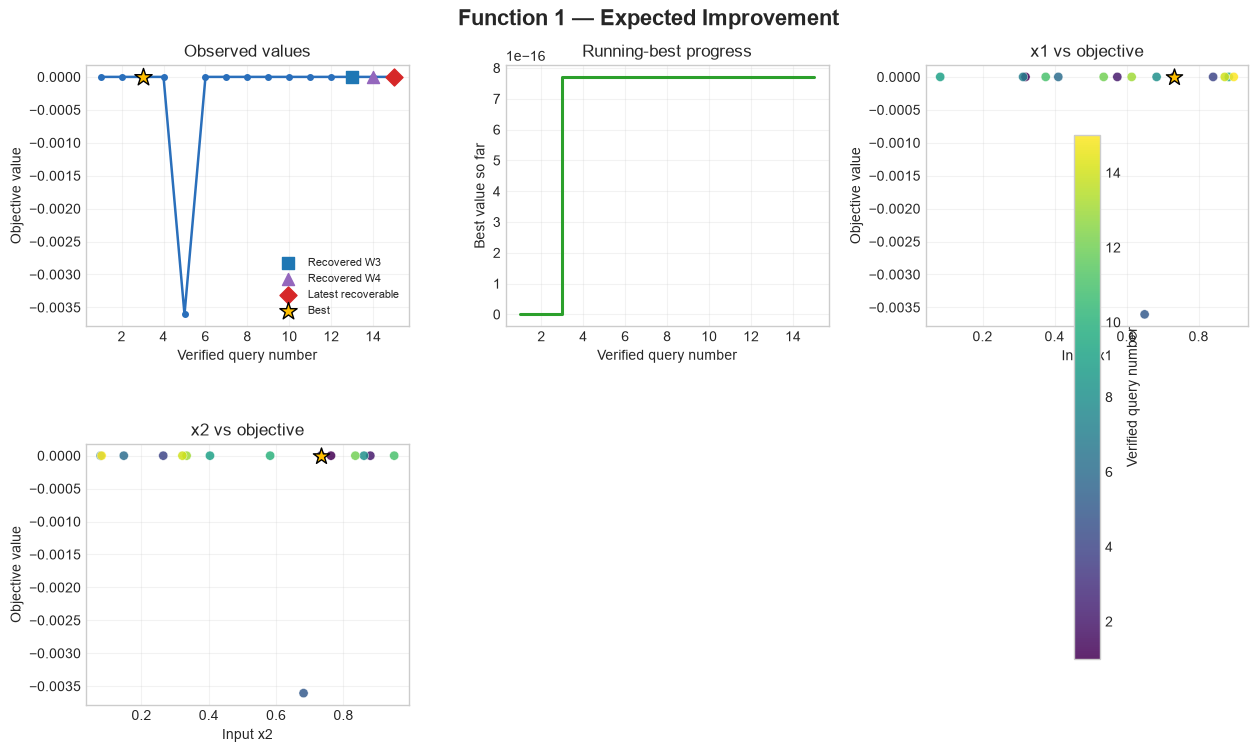

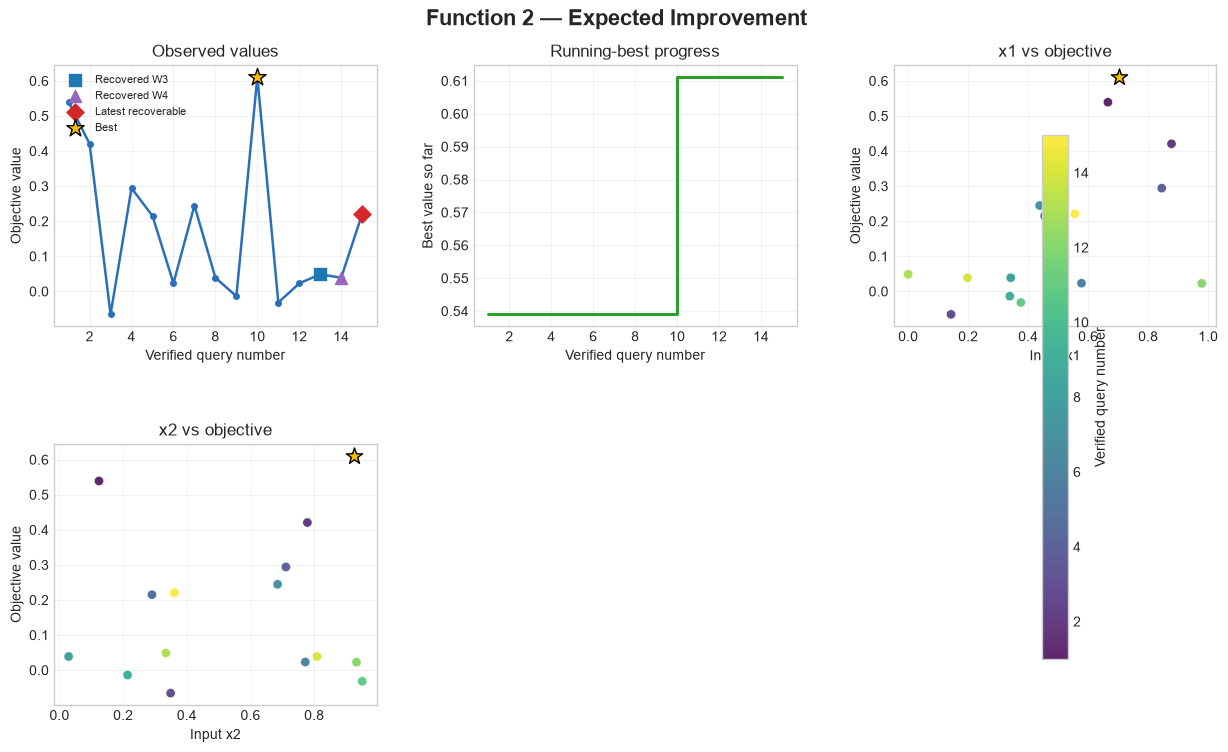

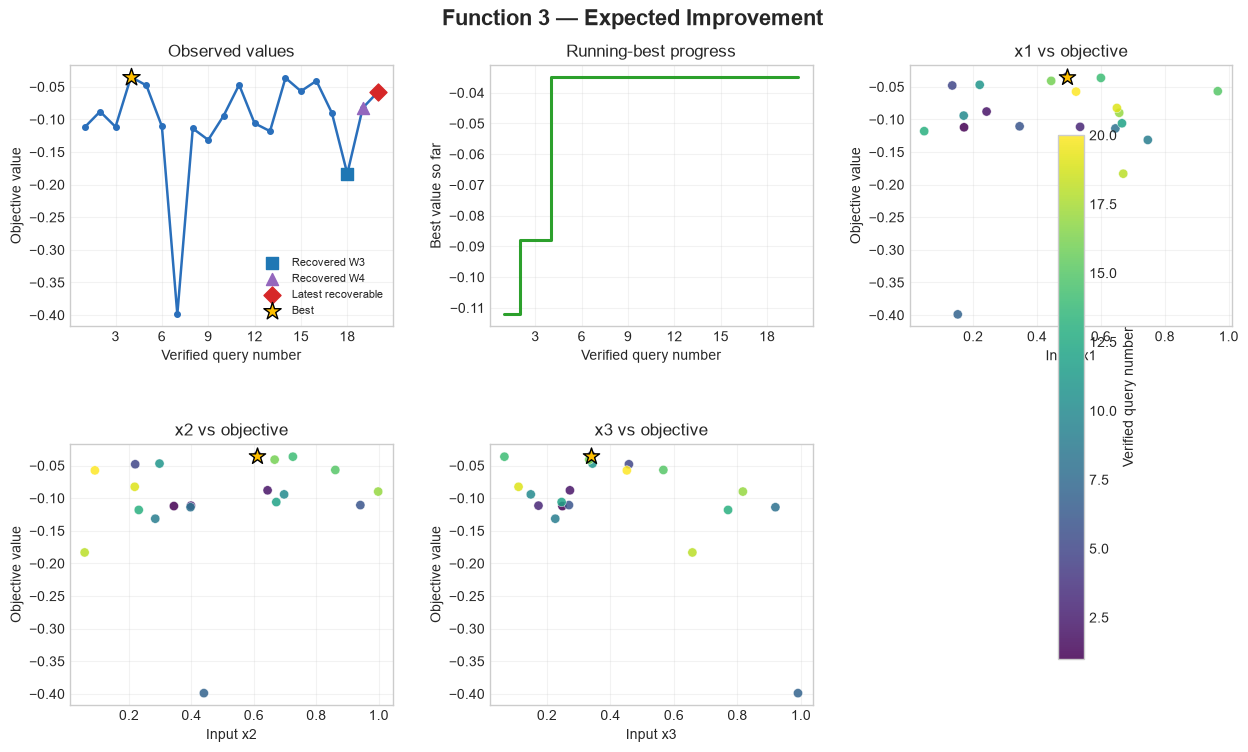

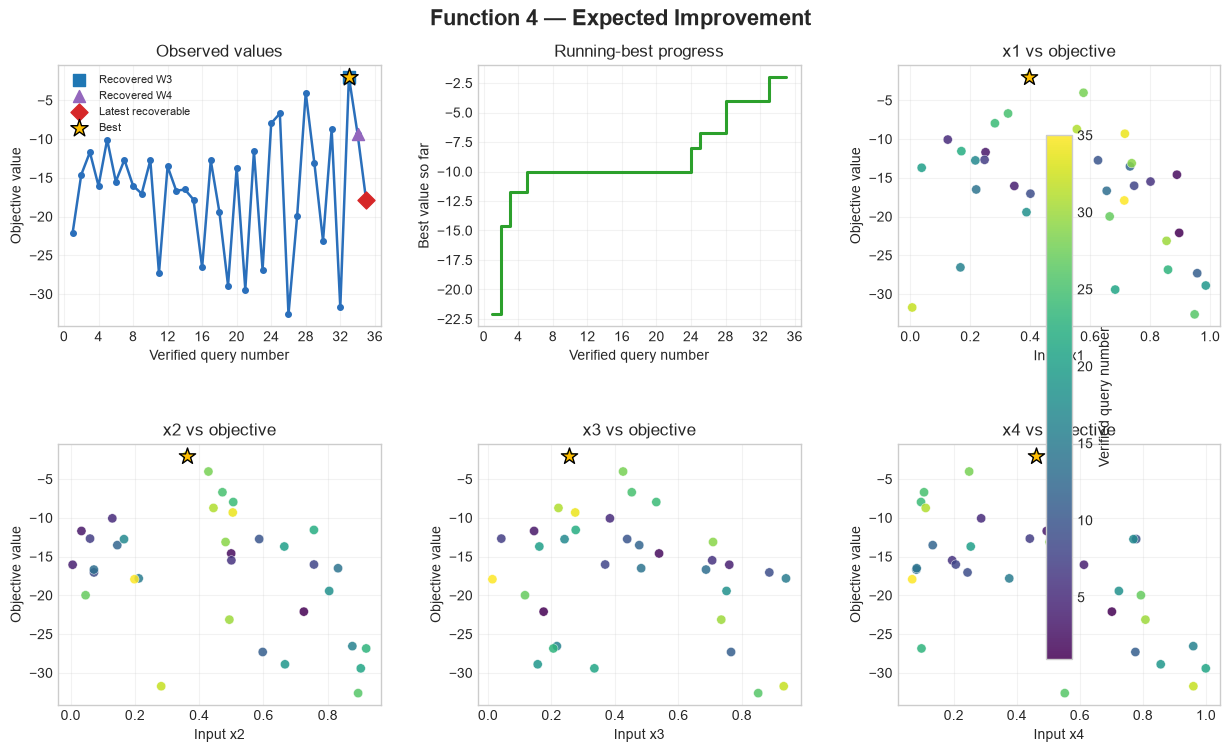

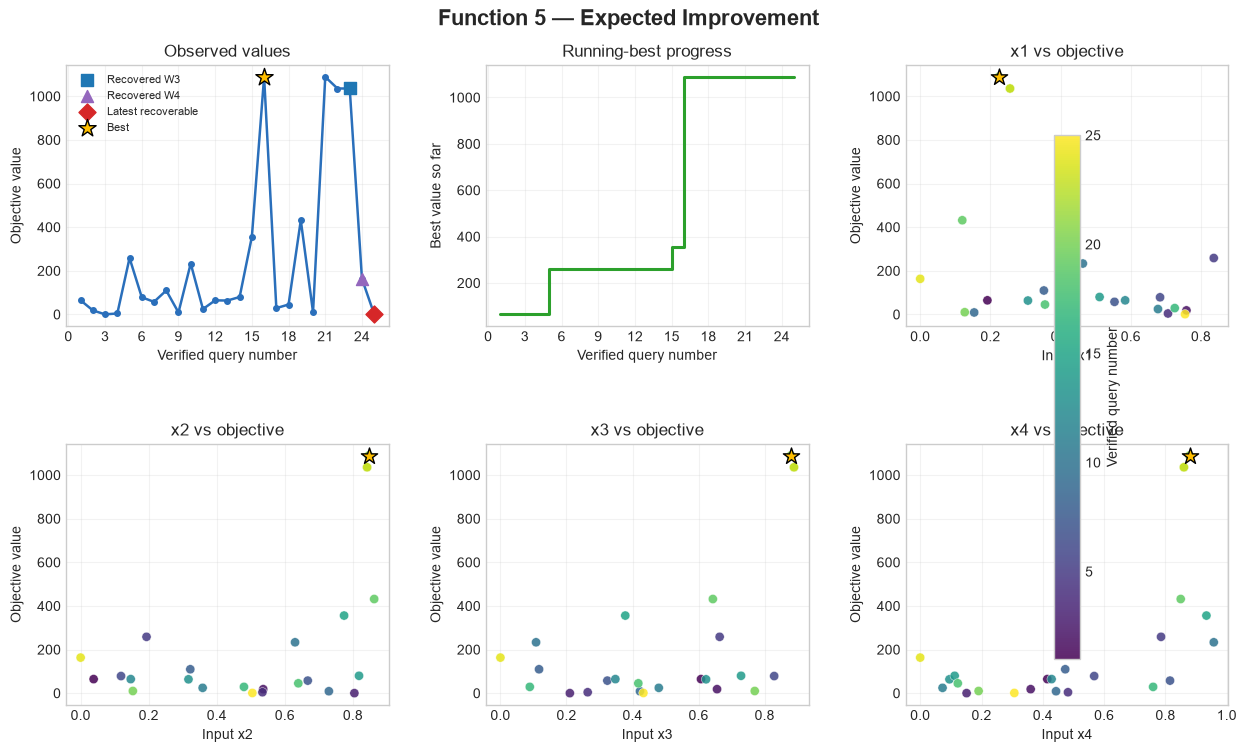

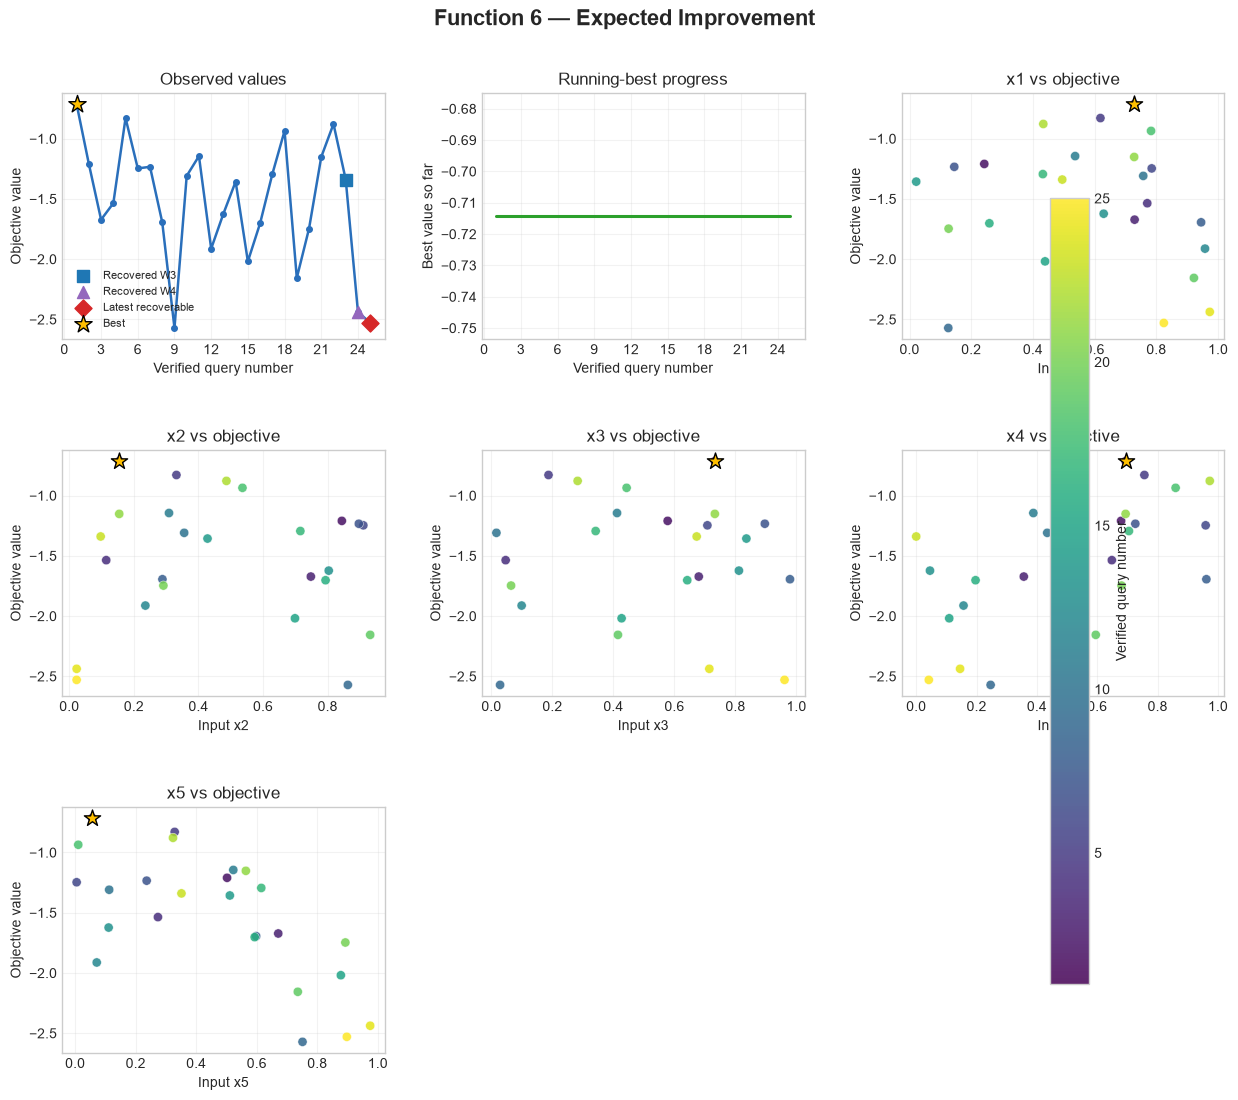

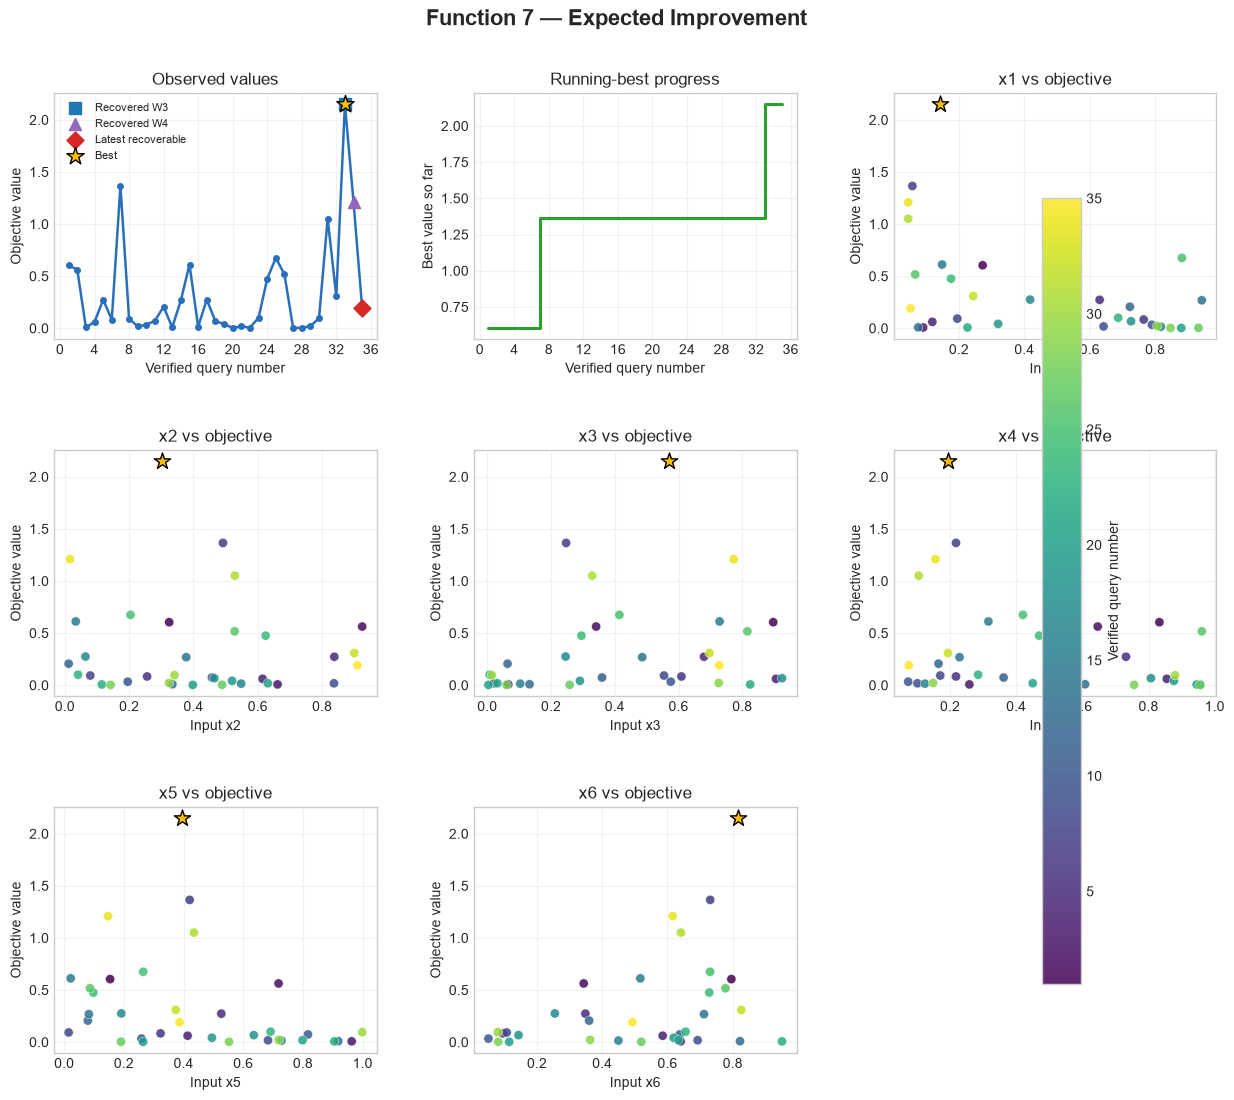

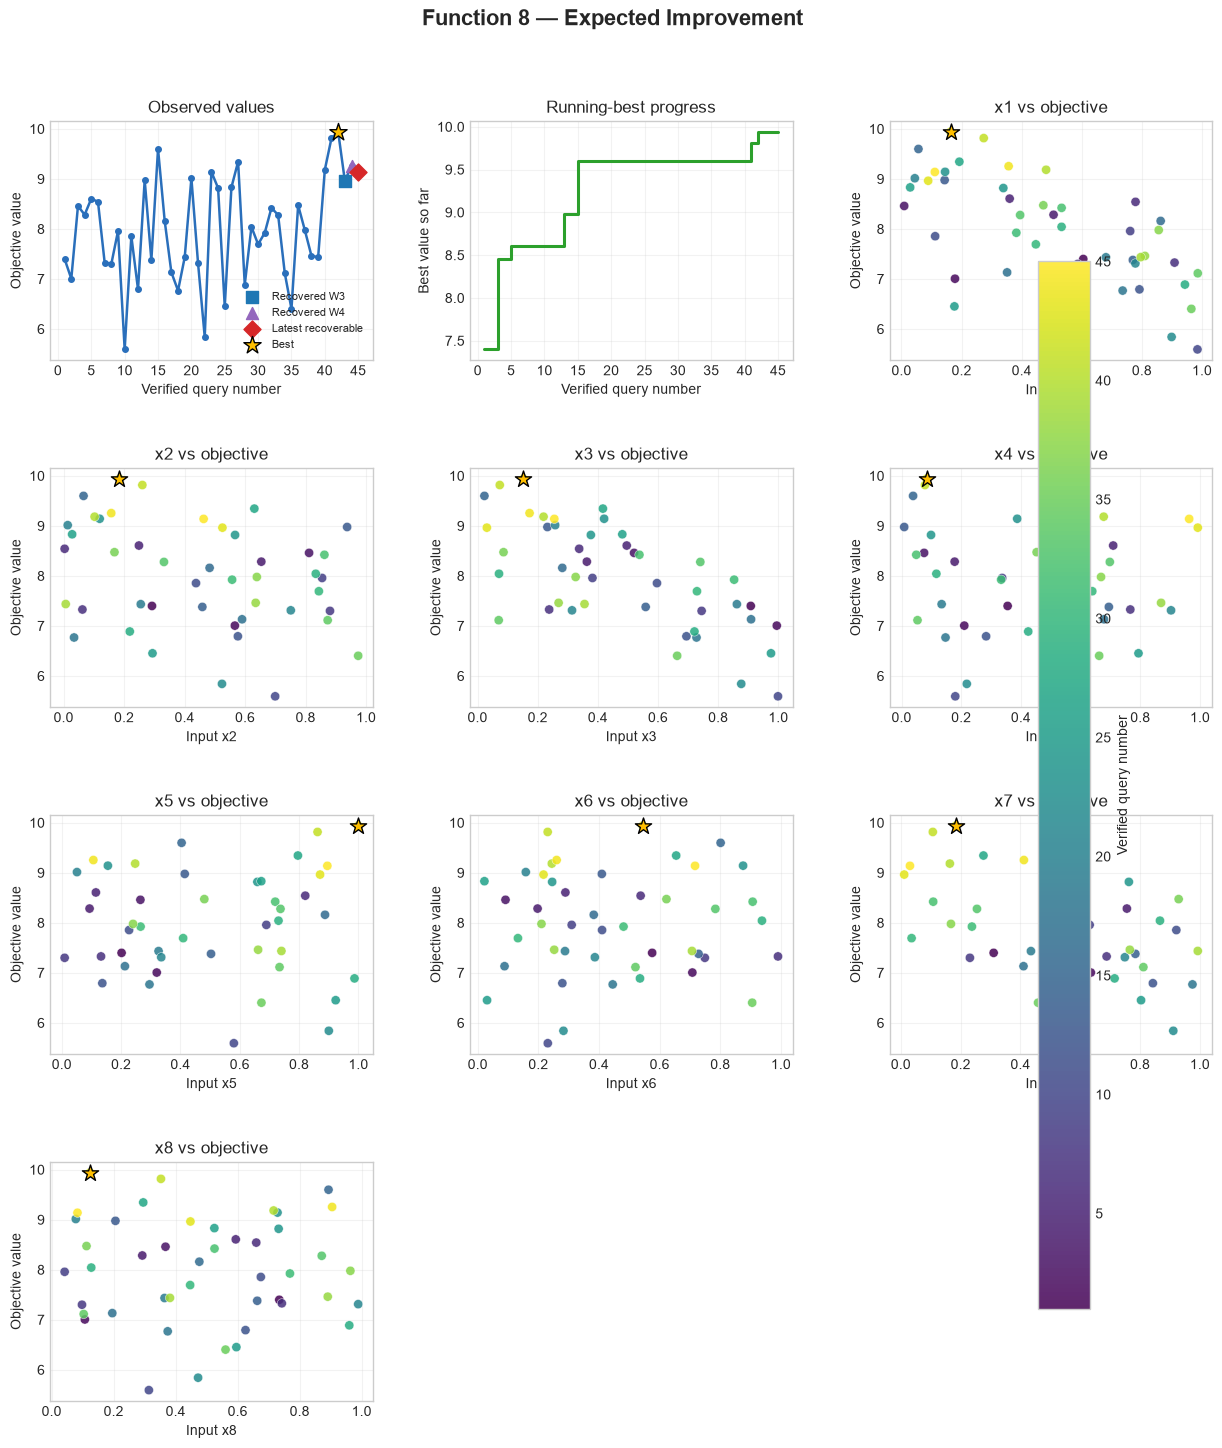

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_verified(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3; rows=math.ceil(panels/cols); fig,axes=plt.subplots(rows,cols,figsize=(15,4*rows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-3],y[-3],marker='s',color='#1f77b4',s=70,zorder=4,label='Recovered W3'); axes[0].scatter(q[-2],y[-2],marker='^',color='#9467bd',s=75,zorder=4,label='Recovered W4'); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Latest recoverable'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Best'); axes[0].set(xlabel='Verified query number',ylabel='Objective value',title='Observed values'); axes[0].legend(fontsize=8); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Verified query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True)); colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]): colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Verified query number',shrink=.85); fig.suptitle(f'Function {fn} — Expected Improvement',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

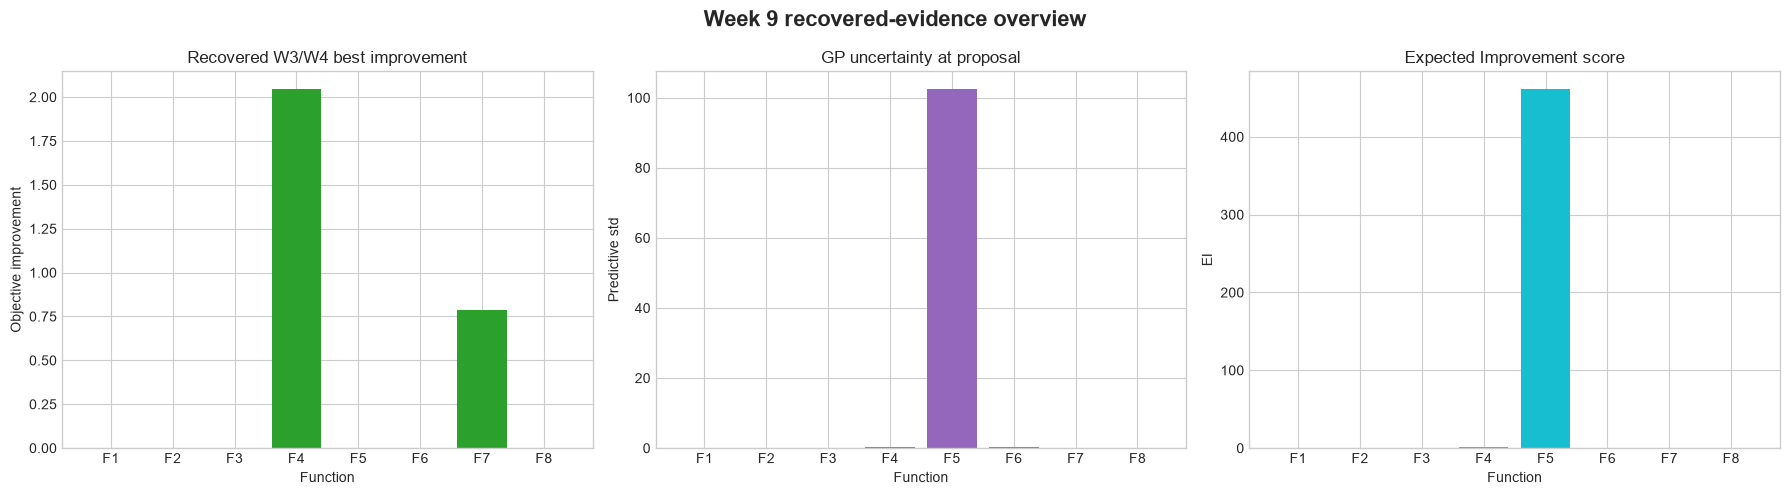

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Recovered-round improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Recovered-round improvement'],color=colours); axes[0].set(title='Recovered W3/W4 best improvement',xlabel='Function',ylabel='Objective improvement')
axes[1].bar(proposal_summary['Function'],proposal_summary['Predictive std'],color='#9467bd'); axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Expected Improvement'],color='#17becf'); axes[2].set(title='Expected Improvement score',xlabel='Function',ylabel='EI')
fig.suptitle('Week 9 recovered-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:15,2:15,3:20,4:35,5:25,6:25,7:35,8:45}
for fn in FUNCTIONS:
    X,y=load_verified(fn); s=summarize(fn); q=week9_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],)
    assert np.allclose(X[-3:-1],ROUNDS_Q[fn][2:4]) and np.allclose(y[-3:-1],ROUNDS_Y[fn][2:4]); assert np.allclose(X[-1],W6Q[fn]) and np.isclose(y[-1],W6Y[fn])
    assert s['Best query']==int(np.argmax(y))+1 and s['Recovered-round improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==215 and len(performance)==len(proposal_summary)==len(week9_queries)==8
assert performance['Evidence gaps'].eq('Weeks 5 and 7 pending').all()
print('All Week 9 recovered-data, performance, EI proposal, and plotting checks passed.')

All Week 9 recovered-data, performance, EI proposal, and plotting checks passed.
